# Run MT-KCD on cleaned MASS data

Runs the MT-KCD K-complex detector on the whole-night cleaned FIFs (`SS2_Results/New/`).  
Extracts N2 segments, runs the detector on concatenated N2, maps detections back to absolute time, then compares against expert E1 KC annotations from MASS dataset.

**Outputs** saved to `SS2_Results/New/mtkcd_results/`:
- `mtkcd_all_detections.csv` — every detection with absolute times, per subject
- `mtkcd_validation_per_subject.csv` — sensitivity / precision / F1 per subject
- `mtkcd_failed_subjects.csv`

In [10]:
import sys
import numpy as np
import pandas as pd
import mne
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
from fractions import Fraction
from scipy.signal import resample_poly

warnings.filterwarnings("ignore")

CLEAN_DIR  = Path("/Users/elizabethkaplan/Desktop/SS2_Results/New")
MTKCD_REPO = Path("/Users/elizabethkaplan/Desktop/MT-KCD/MT-KCD-code")
OUT_DIR    = CLEAN_DIR / "mtkcd_results"
OUT_DIR.mkdir(exist_ok=True)

sys.path.append(str(MTKCD_REPO))
from mtkcd.MTKCD import MTKCD
from mtkcd.MTKCDParameters import MTKCDParameters

In [5]:
#channel to score 
EEG_CH          = "C3"
#sampling freq mtkcd expects 
FS_MTKCD        = 200
#amount of time between annotations to consider overlapping (experts vs mtkcd)
MATCH_TOLERANCE = 1.0   # seconds
N2_LABEL        = "Sleep stage 2"

In [6]:
#from mtkcd github https://github.com/ghbso/MT-KCD
def make_mtkcd_params(fs=200):
    p = MTKCDParameters
    p.bpf_lower = 0.3
    p.bpf_upper = 35
    p.Fs        = fs
    p.L         = 1 * fs
    p.delta_j   = int(0.05 * fs)
    p.delta_f   = 4
    p.f_max     = 3
    p.q         = 95
    p.i_short   = int((0.5 * fs) / p.delta_j)
    p.i_backg   = int((5.0 * fs) / p.delta_j)
    p.l_smth    = int(0.15 * fs)
    p.l_backg   = int(5.0 * fs)
    p.A_min     = 75
    p.D_max     = 2 * fs
    return p

#match expert and alg annotations
def count_matched(reference, detected, tol):
    matched = 0
    for t in reference:
        if len(detected) > 0 and np.any(np.abs(detected - t) <= tol):
            matched += 1
    return matched

In [7]:
subject_dirs     = sorted([p for p in CLEAN_DIR.iterdir()
                            if p.is_dir() and p.name.startswith("01-02-")])
performance_rows = []
all_detections   = []
failed           = []

for subj_path in subject_dirs:
    subj_id    = subj_path.name
    fif_path   = subj_path / "cleaned" / f"{subj_id}_cleaned_raw.fif"
    annot_path = subj_path / "cleaned" / f"{subj_id}_annotations.csv"

    if not fif_path.exists() or not annot_path.exists():
        print(f"[SKIP] {subj_id}: missing files")
        failed.append({"subject": subj_id, "reason": "missing files"})
        continue

    print(f"\nProcessing {subj_id} ...")

    try:
        raw      = mne.io.read_raw_fif(str(fif_path), preload=False, verbose=False)
        annot_df = pd.read_csv(annot_path)
        sfreq    = raw.info["sfreq"]
        ch_idx   = raw.ch_names.index(EEG_CH)

        # manual KC onsets (absolute time)
        kc_mask       = annot_df["description"].str.lower().str.contains("kcomplex")
        manual_onsets = annot_df[kc_mask]["onset_s"].to_numpy()

        if len(manual_onsets) == 0:
            print(f"  [SKIP] no manual KCs")
            failed.append({"subject": subj_id, "reason": "no manual KCs"})
            continue

        # N2 intervals
        n2_segs = annot_df[annot_df["description"] == N2_LABEL][["onset_s", "duration_s"]].copy()
        n2_segs["offset_s"] = n2_segs["onset_s"] + n2_segs["duration_s"]

        if len(n2_segs) == 0:
            print(f"  [SKIP] no N2 annotations")
            failed.append({"subject": subj_id, "reason": "no N2 annotations"})
            continue

        # extract N2 signal + build absolute-time offset map
        n2_chunks     = []
        seg_abs_start = []   # absolute start of each chunk
        seg_n2_start  = []   # position of each chunk in concatenated N2 signal
        n2_cursor     = 0.0

        for _, seg in n2_segs.iterrows():
            t0 = float(seg["onset_s"])
            t1 = min(float(seg["offset_s"]), raw.times[-1])
            i0, i1 = int(t0 * sfreq), int(t1 * sfreq)
            if i1 <= i0:
                continue
            chunk = raw.get_data(picks=[ch_idx], start=i0, stop=i1)[0] * 1e6
            n2_chunks.append(chunk)
            seg_abs_start.append(t0)
            seg_n2_start.append(n2_cursor)
            n2_cursor += len(chunk) / sfreq

        if not n2_chunks:
            print(f"  [SKIP] N2 extraction failed")
            failed.append({"subject": subj_id, "reason": "N2 extraction failed"})
            continue

        n2_signal       = np.concatenate(n2_chunks)
        n2_duration_min = len(n2_signal) / sfreq / 60
        print(f"  N2: {n2_duration_min:.1f} min  |  manual KCs: {len(manual_onsets)}")

        # resample to 200 Hz
        ratio  = Fraction(FS_MTKCD / sfreq).limit_denominator()
        n2_200 = resample_poly(n2_signal, up=ratio.numerator, down=ratio.denominator)

        # run MT-KCD
        params  = make_mtkcd_params(FS_MTKCD)
        kc_out  = MTKCD().mtkcd(n2_200, params)

        if not kc_out:
            print(f"  MT-KCD: 0 detections")
            performance_rows.append({
                "subject": subj_id, "n2_duration_min": n2_duration_min,
                "n_manual_kc": len(manual_onsets), "n_mtkcd_kc": 0,
                "manual_matched_by_mtkcd": 0, "mtkcd_matched_to_manual": 0,
                "sensitivity": 0, "precision": np.nan, "f1": np.nan,
            })
            continue

        det_df             = pd.DataFrame(kc_out, columns=["Start_n2", "End_n2"])
        det_df["Duration"] = det_df["End_n2"] - det_df["Start_n2"]

        # map N2-relative → absolute time (mtkcd only runs on N2)
        seg_abs_start = np.array(seg_abs_start)
        seg_n2_start  = np.array(seg_n2_start)

        def n2_to_abs(t_n2):
            idx = np.clip(np.searchsorted(seg_n2_start, t_n2, side="right") - 1,
                          0, len(seg_abs_start) - 1)
            return seg_abs_start[idx] + (t_n2 - seg_n2_start[idx])

        det_df["Start"]    = det_df["Start_n2"].apply(n2_to_abs)
        det_df["End"]      = det_df["End_n2"].apply(n2_to_abs)
        det_df["Midpoint"] = (det_df["Start"] + det_df["End"]) / 2
        det_df["subject"]  = subj_id
        det_df["channel"]  = EEG_CH
        all_detections.append(det_df[["subject", "channel", "Start", "End",
                                       "Duration", "Midpoint"]])

        # metrics
        mtkcd_onsets   = det_df["Start"].to_numpy()
        #match events based on overlap tolernace 
        matched_manual = count_matched(manual_onsets, mtkcd_onsets, MATCH_TOLERANCE)
        matched_mtkcd  = count_matched(mtkcd_onsets, manual_onsets, MATCH_TOLERANCE)
        #mtkcd performance based on E1 annotations 
        sensitivity    = matched_manual / len(manual_onsets)
        precision      = matched_mtkcd / len(mtkcd_onsets) if len(mtkcd_onsets) > 0 else np.nan
        f1             = (2 * sensitivity * precision / (sensitivity + precision)
                          if sensitivity + precision > 0 else np.nan)

        print(f"  MT-KCD: {len(mtkcd_onsets)}  |  "
              f"sens={sensitivity:.3f}  prec={precision:.3f}  F1={f1:.3f}")

        performance_rows.append({
            "subject":                 subj_id,
            "n2_duration_min":         n2_duration_min,
            "n_manual_kc":             len(manual_onsets),
            "n_mtkcd_kc":              len(mtkcd_onsets),
            "manual_matched_by_mtkcd": matched_manual,
            "mtkcd_matched_to_manual": matched_mtkcd,
            "sensitivity":             sensitivity,
            "precision":               precision,
            "f1":                      f1,
            "manual_kc_rate_min":      len(manual_onsets) / n2_duration_min,
            "mtkcd_kc_rate_min":       len(mtkcd_onsets)  / n2_duration_min,
        })

    except Exception as e:
        print(f"  [FAIL] {subj_id}: {e}")
        failed.append({"subject": subj_id, "reason": str(e)})

#save data locally as csv 
perf_df = pd.DataFrame(performance_rows)
all_df  = pd.concat(all_detections, ignore_index=True) if all_detections else pd.DataFrame()
fail_df = pd.DataFrame(failed)

perf_df.to_csv(OUT_DIR / "mtkcd_validation_per_subject.csv", index=False)
all_df.to_csv( OUT_DIR / "mtkcd_all_detections.csv",         index=False)
fail_df.to_csv(OUT_DIR / "mtkcd_failed_subjects.csv",        index=False)

display(perf_df[["subject", "n_manual_kc", "n_mtkcd_kc",
                 "sensitivity", "precision", "f1"]].round(3))

print("\nDone.")

#print(f"\nMean sensitivity: {perf_df['sensitivity'].mean():.3f}")
#print(f"Mean precision:   {perf_df['precision'].mean():.3f}")
#print(f"Mean F1:          {perf_df['f1'].mean():.3f}")
#print(f"\nResults saved to: {OUT_DIR}")


Processing 01-02-0001 ...
  N2: 248.3 min  |  manual KCs: 409
  MT-KCD: 215  |  sens=0.399  prec=0.721  F1=0.513

Processing 01-02-0002 ...
  N2: 303.6 min  |  manual KCs: 637
  MT-KCD: 395  |  sens=0.567  prec=0.891  F1=0.693

Processing 01-02-0003 ...
  N2: 165.3 min  |  manual KCs: 533
  MT-KCD: 246  |  sens=0.366  prec=0.760  F1=0.494

Processing 01-02-0004 ...
  N2: 238.6 min  |  manual KCs: 607
  MT-KCD: 337  |  sens=0.357  prec=0.591  F1=0.445

Processing 01-02-0005 ...
  N2: 210.9 min  |  manual KCs: 419
  MT-KCD: 121  |  sens=0.177  prec=0.595  F1=0.272

Processing 01-02-0006 ...
  N2: 225.3 min  |  manual KCs: 674
  MT-KCD: 229  |  sens=0.349  prec=0.939  F1=0.508

Processing 01-02-0007 ...
  N2: 231.3 min  |  manual KCs: 436
  MT-KCD: 284  |  sens=0.296  prec=0.426  F1=0.349

Processing 01-02-0008 ...
  N2: 181.9 min  |  manual KCs: 712
  MT-KCD: 395  |  sens=0.323  prec=0.527  F1=0.400

Processing 01-02-0009 ...
  N2: 246.3 min  |  manual KCs: 895
  MT-KCD: 424  |  sens=0.

,subject,n_manual_kc,n_mtkcd_kc,sensitivity,precision,f1
0,01-02-0001,409,215,0.399,0.721,0.513
1,01-02-0002,637,395,0.567,0.891,0.693
2,01-02-0003,533,246,0.366,0.760,0.494
3,01-02-0004,607,337,0.357,0.591,0.445
4,01-02-0005,419,121,0.177,0.595,0.272
5,01-02-0006,674,229,0.349,0.939,0.508
6,01-02-0007,436,284,0.296,0.426,0.349
7,01-02-0008,712,395,0.323,0.527,0.400
8,01-02-0009,895,424,0.378,0.733,0.499
9,01-02-0010,999,434,0.370,0.793,0.505



Done.


## KCs marked by experts and MTKCD

In [8]:
#reads in previously calculated performance of mtkcd vs expert and all annotations 
#don't need to run cells above for this to work 
perf_df = pd.read_csv(OUT_DIR / "mtkcd_validation_per_subject.csv")
all_df  = pd.read_csv(OUT_DIR / "mtkcd_all_detections.csv")

matched_pairs = []

for subj_id in perf_df["subject"]:
    annot_path = CLEAN_DIR / subj_id / "cleaned" / f"{subj_id}_annotations.csv"
    annot_df   = pd.read_csv(annot_path)
    kc_mask    = annot_df["description"].str.lower().str.contains("kcomplex")
    expert_df  = annot_df[kc_mask].copy()

    subj_det     = all_df[all_df["subject"] == subj_id].copy()
    mtkcd_onsets = subj_det["Start"].to_numpy()
    mtkcd_durs   = subj_det["Duration"].to_numpy()

    for _, row in expert_df.iterrows():
        if len(mtkcd_onsets) == 0:
            continue
        diffs = mtkcd_onsets - row["onset_s"]
        idx   = np.argmin(np.abs(diffs))
        if np.abs(diffs[idx]) <= MATCH_TOLERANCE:
            matched_pairs.append({
                "subject":    subj_id,
                "expert_onset": row["onset_s"],
                "mtkcd_onset":  mtkcd_onsets[idx],
                "offset_s":     diffs[idx],   # positive = MTKCD is later
                "expert_dur":   row["duration_s"],
                "mtkcd_dur":    mtkcd_durs[idx],
            })

matched_df = pd.DataFrame(matched_pairs)
#numver of events identified by both expert and MTKCD
print(f"Matched pairs: {len(matched_df)}")
#print(f"Mean MTKCD − expert offset: {matched_df['offset_s'].mean():.3f} s  (std {matched_df['offset_s'].std():.3f} s)")

Matched pairs: 4092


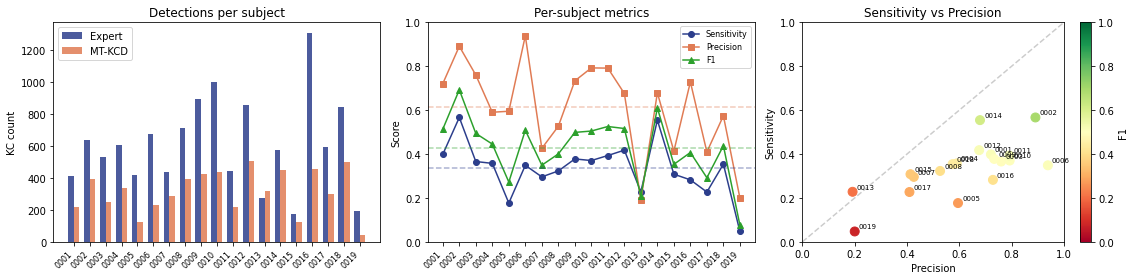

In [11]:
##plot performance of expert vs algorithm 
subjs      = perf_df["subject"].str.extract(r"(\d+)$")[0]  # short labels
x          = np.arange(len(perf_df))
w          = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# detection counts
ax = axes[0]
ax.bar(x - w/2, perf_df["n_manual_kc"],  w, label="Expert",  color="#2c3e8c", alpha=0.85)
ax.bar(x + w/2, perf_df["n_mtkcd_kc"],   w, label="MT-KCD",  color="#e07b54", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(subjs, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("KC count"); ax.set_title("Detections per subject")
ax.legend()

# sensitivity / precision / F1
ax = axes[1]
ax.plot(x, perf_df["sensitivity"], "o-", color="#2c3e8c", label="Sensitivity")
ax.plot(x, perf_df["precision"],   "s-", color="#e07b54", label="Precision")
ax.plot(x, perf_df["f1"],          "^-", color="#2ca02c", label="F1")
ax.axhline(perf_df["sensitivity"].mean(), color="#2c3e8c", linestyle="--", alpha=0.4)
ax.axhline(perf_df["precision"].mean(),   color="#e07b54", linestyle="--", alpha=0.4)
ax.axhline(perf_df["f1"].mean(),          color="#2ca02c", linestyle="--", alpha=0.4)
ax.set_xticks(x); ax.set_xticklabels(subjs, rotation=45, ha="right", fontsize=8)
ax.set_ylim(0, 1); ax.set_ylabel("Score"); ax.set_title("Per-subject metrics")
ax.legend(fontsize=8)

# sensitivity vs precision scatter
ax = axes[2]
sc = ax.scatter(perf_df["precision"], perf_df["sensitivity"],
                c=perf_df["f1"], cmap="RdYlGn", vmin=0, vmax=1, s=80, zorder=3)
for i, sid in enumerate(subjs):
    ax.annotate(sid, (perf_df["precision"].iloc[i], perf_df["sensitivity"].iloc[i]),
                fontsize=7, textcoords="offset points", xytext=(4, 3))
plt.colorbar(sc, ax=ax, label="F1")
ax.set_xlabel("Precision"); ax.set_ylabel("Sensitivity")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.plot([0,1],[0,1], "k--", alpha=0.2)
ax.set_title("Sensitivity vs Precision")

plt.tight_layout()
plt.show()